## 1. Осциллятор ван дер Поля

$$\ddot{x}-(\lambda-x^2)\dot{x}+\omega_{0}^2x=0$$

### Карта седел

$$
\dot{x} = y = 0\\
\dot{y} = (\lambda - x^2) y - \omega_0^2 x = 0 \\
\\
J = \begin{bmatrix}
  0 & 
    1 \\[1ex]
  -2xy-\omega_{0}^2 & 
    \lambda - x^2 \\[1ex]
\end{bmatrix} \\
J_{x=y=0} = \begin{bmatrix}
  0 & 
    1 \\[1ex]
  -\omega_{0}^2 & 
    \lambda \\[1ex]
\end{bmatrix} \\
\mu^2 - \lambda \mu + \omega_0^2 = 0 \\
\mu_{1,2} = \frac{\lambda \pm \sqrt{\lambda^2 - 4 \omega_0^2}}{2}
$$

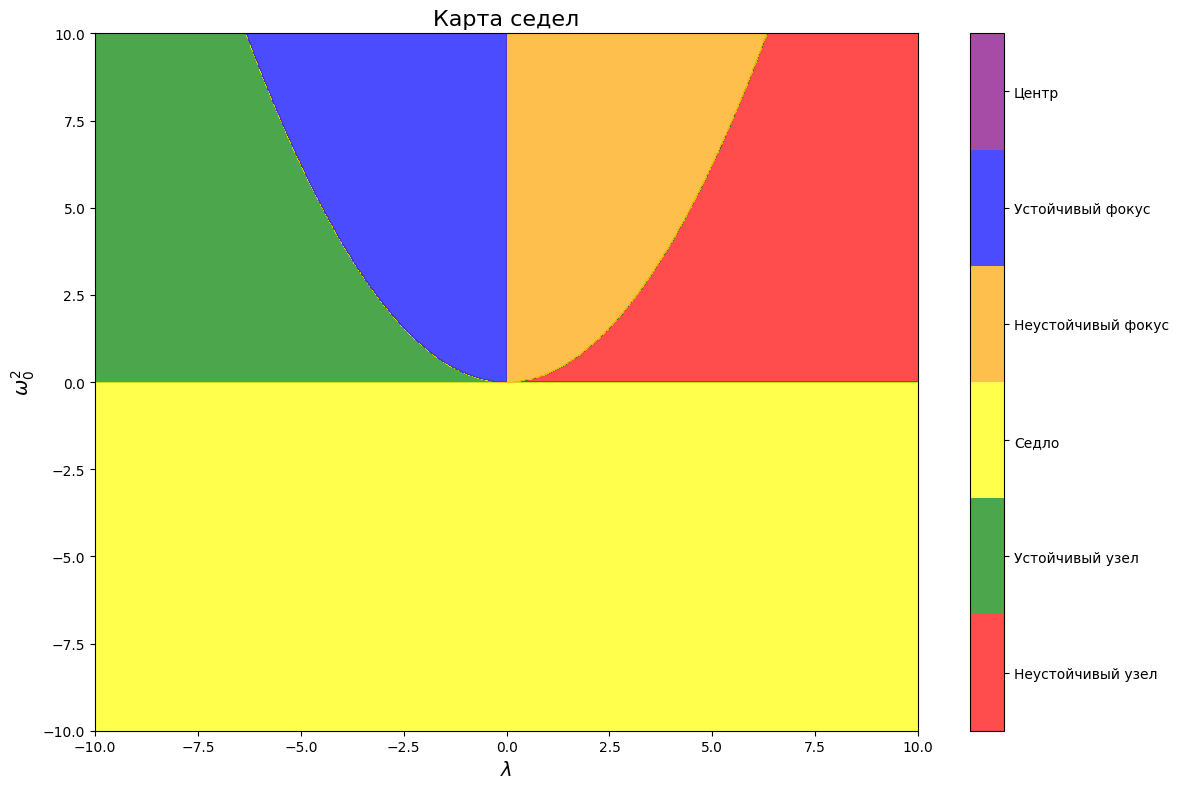

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def get_equilibrium_type(lambda_val, w0_sq_val):
    D = lambda_val**2 - 4 * w0_sq_val
    
    if D > 0:
        l1 = (lambda_val + np.sqrt(D)) / 2
        l2 = (lambda_val - np.sqrt(D)) / 2
        if l1 > 0 and l2 > 0:
            return 1  # неустойчивый узел
        elif l1 < 0 and l2 < 0:
            return 2  # устойчивый узел
        else:
            return 3  # седло
    elif D < 0:
        real_part = lambda_val / 2
        if real_part > 0:
            return 4  # неустойчивый фокус
        elif real_part < 0:
            return 5  # устойчивый фокус
        else:
            return 6  # центр
    else:  # D == 0
        real_part = lambda_val / 2
        if real_part > 0:
            return 1  # неустойчивый узел
        elif real_part < 0:
            return 2  # устойчивый узел
        else:
            return 6  # центр

def get_equilibrium_type_map(lambda_vals, w0_sq_vals):
    Lambda, W0_sq = np.meshgrid(lambda_vals, w0_sq_vals)
    equilibrium_type = np.zeros_like(Lambda)
    for i in range(len(lambda_vals)):
        for j in range(len(w0_sq_vals)):
            equilibrium_type[j, i] = get_equilibrium_type(lambda_vals[i], w0_sq_vals[j])
    return equilibrium_type


lambda_vals = np.linspace(-10, 10, 1000)
w0_sq_vals = np.linspace(-10, 10, 1000)

equilibrium_type = get_equilibrium_type_map(lambda_vals, w0_sq_vals)

type_labels = {
    1: 'Неустойчивый узел',
    2: 'Устойчивый узел', 
    3: 'Седло',
    4: 'Неустойчивый фокус',
    5: 'Устойчивый фокус',
    6: 'Центр'
}

plt.figure(figsize=(12, 8))
contour = plt.contourf(lambda_vals, w0_sq_vals, equilibrium_type, 
                      levels=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5], 
                      colors=['red', 'green', 'yellow', 'orange', 'blue', 'purple'], 
                      alpha=0.7)

cbar = plt.colorbar(contour, ticks=[1, 2, 3, 4, 5, 6])
cbar.ax.set_yticklabels([type_labels[i] for i in [1, 2, 3, 4, 5, 6]])

plt.xlabel(r'$\lambda$', fontsize=14)
plt.ylabel(r'$\omega_0^2$', fontsize=14)
plt.title('Карта седел', fontsize=16)

plt.tight_layout()
plt.show()

### Бифуркационное дерево

Computing bifurcation diagram: 100%|██████████| 100/100 [00:07<00:00, 13.48it/s]


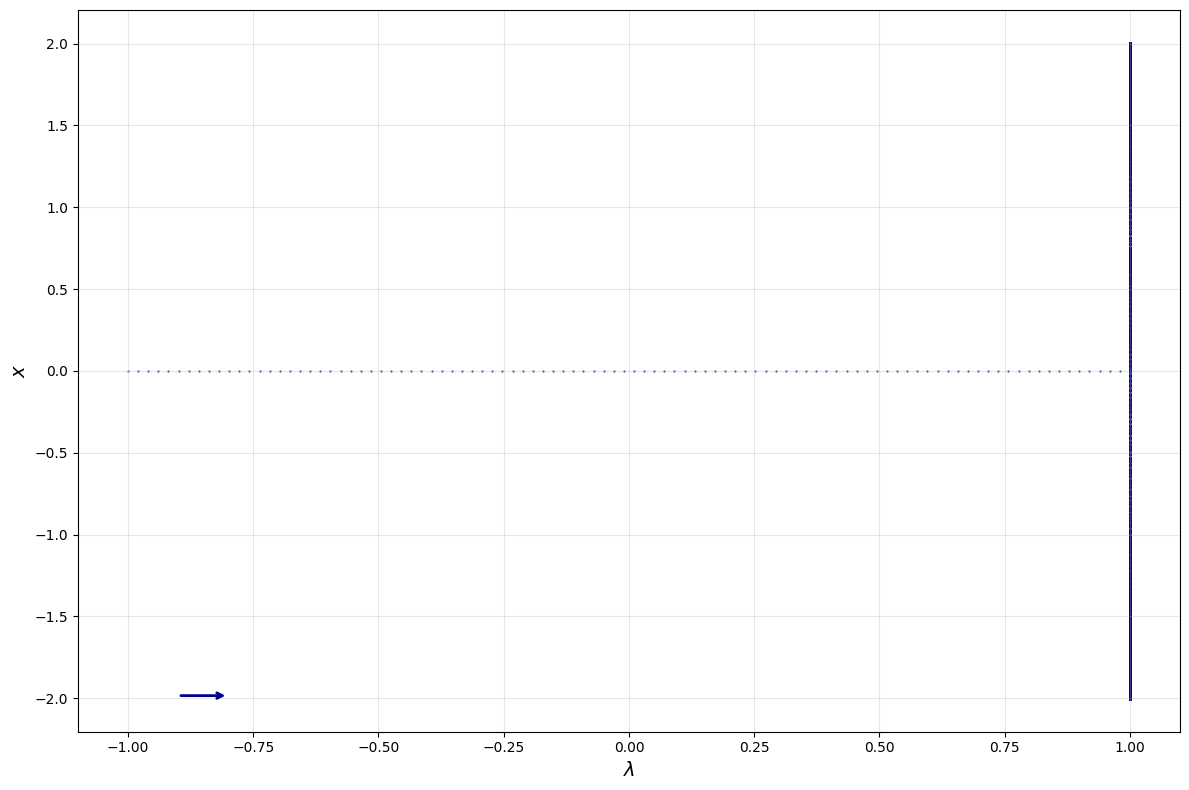

In [7]:
def secant_plane(state):
    return state[0]

from systems import van_der_pol_rk4
from utils import plot_bifurcation_diagram

plot_bifurcation_diagram(
    evolution_operator=van_der_pol_rk4,
    state=[0.2, 0.3],
    dt=0.01, 
    n_transient=10, n_attractor=10, 
    secant_plane=secant_plane,
    params=[1.0, 2.0],
    changing_parameter_number=0,
    changing_parameter_range=(-1, 1),
    direction='increase',
    point_size=0.5,
    changing_parameter_num=100
)

Computing bifurcation diagram: 100%|██████████| 100/100 [00:11<00:00,  8.92it/s]


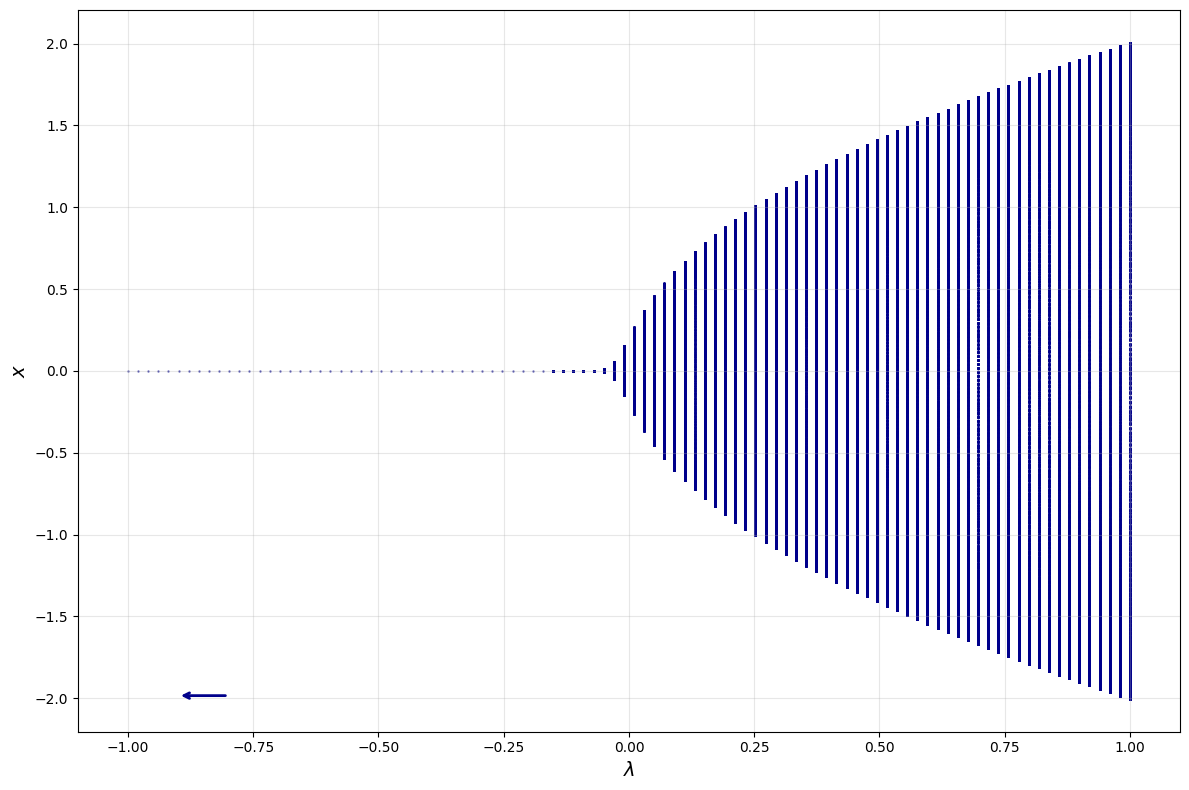

In [8]:
def secant_plane(state):
    return state[0]

from systems import van_der_pol_rk4
from utils import plot_bifurcation_diagram

plot_bifurcation_diagram(
    evolution_operator=van_der_pol_rk4,
    state=[0.2, 0.3],
    dt=0.01, n_transient=10,
    n_attractor=10, 
    secant_plane=secant_plane,
    params=[1.0, 2.0],
    changing_parameter_number=0,
    changing_parameter_range=(-1, 1),
    direction='decrease',
    point_size=0.5, changing_parameter_num=100
)

### 2. Два связанных осцилляторов ван дер Поля

Построить карту режимов для системы 

$$
\ddot{x}_{1}-(\lambda_{1}-x_{1}^2)\dot{x_{1}}+x_{1}+\mu(\dot{x_{1}}-\dot{x_{2}})=0 \\
\ddot{x}_{2}-(\lambda_{2}-x_{2}^2)\dot{x_{2}}+(1+\delta)x_{2}+\mu(\dot{x_{2}}-\dot{x_{1}})=0
$$

как на рис. 1 в [1], попробовать посчитать частоту колебаний внутри языка синхронизации и сравнить с частотами каждой подсистемы.

Карта строится при параметрах $\lambda_{1}=\lambda_{2}=1$ и $\delta\in(-1.5, 30?), \mu\in(0, 3)$

Использовать метод Эно и сечения Пуанкаре для x=0 (m) и y=0 (n). Карта для n, m только для частот.

In [4]:
import numpy as np

def coupled_oscillators(state, params):
    """Функция системы связанных осцилляторов"""
    x1, dx1, x2, dx2 = state
    lambda_, delta, mu = params

    try:
        d2x1 = (lambda_ - x1**2) * dx1 - x1 - mu * (dx1 - dx2)
        d2x2 = (lambda_ - x2**2) * dx2 - (1 + delta) * x2 - mu * (dx2 - dx1)
        
        if np.any(np.isnan([d2x1, d2x2])) or np.any(np.isinf([d2x1, d2x2])):
            return None
            
    except (OverflowError, FloatingPointError, ValueError) as e:
        return None
        
    return np.array([dx1, d2x1, dx2, d2x2])

def secant_plane(state):
    """Секущая плоскость: x2 точка = 0"""
    return state[3]

def rk4_step(state, params, dt):
    """Шаг метода Рунге-Кутта 4-го порядка по времени"""
    try:
        if np.any(np.isnan(state)) or np.any(np.isinf(state)):
            return None
            
        k1 = coupled_oscillators(state, params)
        if k1 is None or np.any(np.isnan(k1)) or np.any(np.isinf(k1)):
            return None
            
        k2 = coupled_oscillators(state + 0.5*dt*k1, params)
        if k2 is None or np.any(np.isnan(k2)) or np.any(np.isinf(k2)):
            return None
            
        k3 = coupled_oscillators(state + 0.5*dt*k2, params)
        if k3 is None or np.any(np.isnan(k3)) or np.any(np.isinf(k3)):
            return None
            
        k4 = coupled_oscillators(state + dt*k3, params)
        if k4 is None or np.any(np.isnan(k4)) or np.any(np.isinf(k4)):
            return None
            
        new_state = state + dt*(k1 + 2*k2 + 2*k3 + k4)/6
        
        if np.any(np.isnan(new_state)) or np.any(np.isinf(new_state)):
            return None
            
        return new_state
        
    except (OverflowError, FloatingPointError, ValueError, TypeError) as e:
        return None

def henon_rk4_step(state, params, dS):
    """
    Правильная реализация метода Эно с использованием РК4
    Согласно оригинальной статье
    """
    # Вычисляем производные в начальной точке
    derivatives0 = coupled_oscillators(state, params)
    if derivatives0 is None:
        return None
    
    H0 = derivatives0[3]  # d2x2
    
    if np.abs(H0) < 1e-12:
        return None
    
    # Вычисляем k1
    k1 = derivatives0 / H0
    
    # Вычисляем производные в первой промежуточной точке
    state1 = state + 0.5 * dS * k1
    derivatives1 = coupled_oscillators(state1, params)
    if derivatives1 is None:
        return None
    
    H1 = derivatives1[3]
    if np.abs(H1) < 1e-12:
        return None
    
    # Вычисляем k2
    k2 = derivatives1 / H1
    
    # Вычисляем производные во второй промежуточной точке
    state2 = state + 0.5 * dS * k2
    derivatives2 = coupled_oscillators(state2, params)
    if derivatives2 is None:
        return None
    
    H2 = derivatives2[3]
    if np.abs(H2) < 1e-12:
        return None
    
    # Вычисляем k3
    k3 = derivatives2 / H2
    
    # Вычисляем производные в третьей промежуточной точке
    state3 = state + dS * k3
    derivatives3 = coupled_oscillators(state3, params)
    if derivatives3 is None:
        return None
    
    H3 = derivatives3[3]
    if np.abs(H3) < 1e-12:
        return None
    
    # Вычисляем k4
    k4 = derivatives3 / H3
    
    # Вычисляем новое состояние
    new_state = state + (dS / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
    
    return new_state

def pass_transient_process(state, params, dt, n_intersections, max_steps=100_000_000) -> np.ndarray | None:
    count = 0
    step_count = 0
    current_state = np.array(state, dtype=np.float64)
    previous_state = None
    
    while count < n_intersections:
        step_count += 1
        if step_count > max_steps:
            return None
        
        previous_state = current_state
        current_state = rk4_step(current_state, params, dt)
        
        if current_state is None:
            return None
            
        if previous_state is not None:
            S_prev = secant_plane(previous_state)
            S_curr = secant_plane(current_state)
            
            if S_prev < 0 and S_curr >= 0:
                count += 1
                
    return current_state

def calculate_period(state, params, dt, n_transient, n_attractor, accuracy=1e-4, secant_plane=secant_plane):
    """
    -1: fixed point
    -2: diverging
    -3: chaotic (n_attractor intersections)
    uint: period
    """
    state = pass_transient_process(state, params, dt, n_transient)
    if state is None:
        return -2
    
    number_of_intersections = 0
    previous_state = None
    first_point = None

    while number_of_intersections < n_attractor:
        previous_state = state
        state = rk4_step(state, params, dt)
        if state is None:
            return -2
        
        if previous_state is not None and np.linalg.norm(state - previous_state) < 1e-12:
            return -1
        
        if previous_state is not None:
            S_prev = secant_plane(previous_state)
            S_curr = secant_plane(state)

            if S_prev < 0 and S_curr >= 0:
                dS = -S_curr
                
                sect_point = henon_rk4_step(state, params, dS)

                if first_point is None:
                    first_point = sect_point
                else:
                    if np.linalg.norm(sect_point - first_point) < accuracy:
                        return number_of_intersections
                
                if sect_point is not None:
                    number_of_intersections += 1
                else:
                    print(f"Error: henon_rk4_step failed at intersection {number_of_intersections+1}")
    
    return -3

In [ ]:
import matplotlib.pyplot as plt

def plot_phase_portrait(state, params, dt, n_transient, n_attractor):
    state = pass_transient_process(state, params, dt, n_transient)
    if state is None:
        return
    xs = []
    ys = []
    dxs = []
    dys = []
    number_of_intersections = 0
    while number_of_intersections < n_attractor:
        last_state = state
        state = rk4_step(state, params, dt)
        if secant_plane(last_state) < 0 and secant_plane(state) >= 0:
            number_of_intersections += 1
        xs.append(state[0])
        ys.append(state[2])
        dxs.append(state[1])
        dys.append(state[3])
    
    fig, axs = plt.subplots(1, 2, figsize=(16, 7))
    axs[0].scatter(xs, dxs, s=0.1)
    axs[0].set_xlabel(r'$x$')
    axs[0].set_ylabel(r'$\dot{x}$')
    axs[0].grid(True)
    axs[1].scatter(ys, dys, s=0.1)
    axs[1].set_xlabel(r'$y$')
    axs[1].set_ylabel(r'$\dot{y}$')
    axs[1].grid(True)
    plt.tight_layout()
    plt.show()

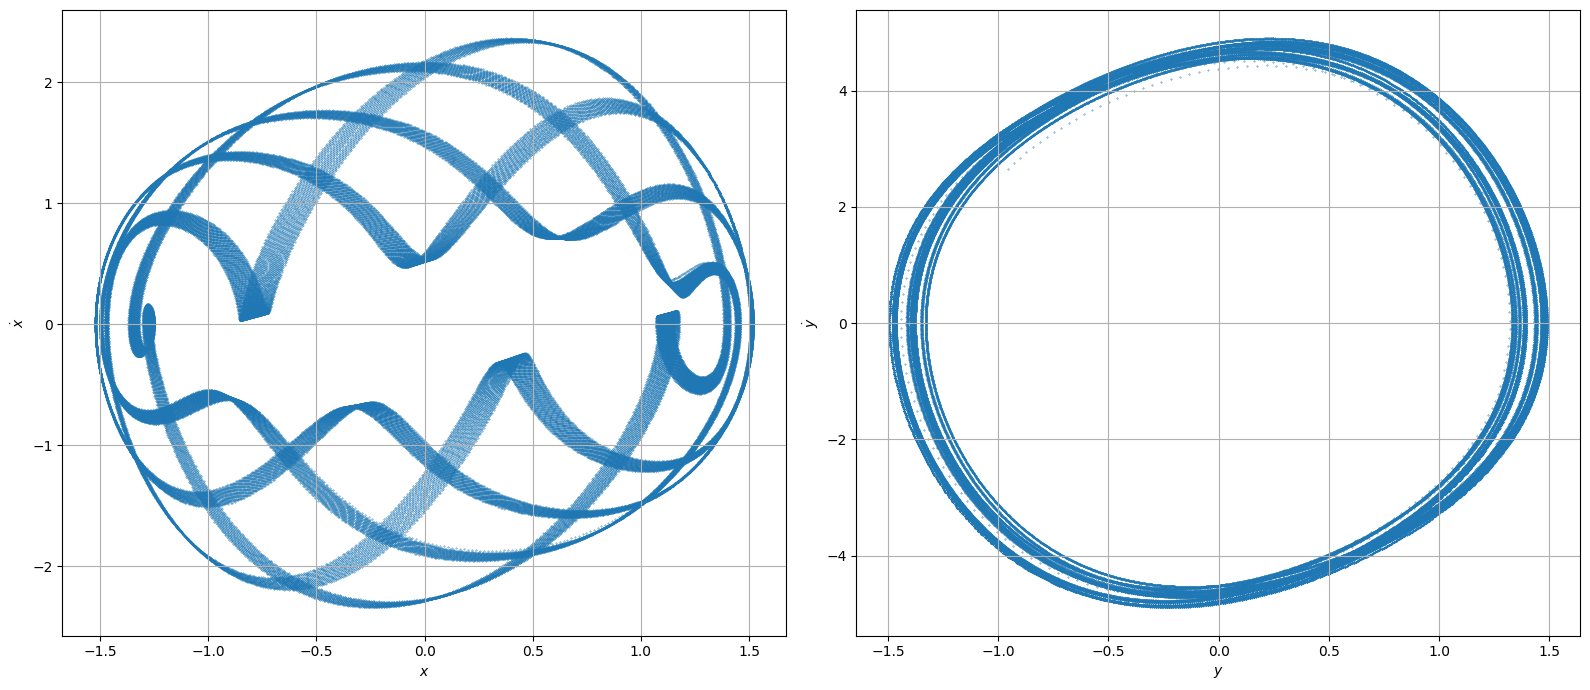

In [30]:
plot_phase_portrait(state=[1.0, 0.0, 1.0, 0.0], params=[1.0, 10.0, 0.5], dt=0.01, n_transient=500, n_attractor=500)

In [2]:
import numpy as np
import plotly.graph_objects as go
from tqdm import tqdm
from multiprocessing import Pool, cpu_count

delta_min, delta_max = -1.5, 9.5
mu_min, mu_max = 0.0, 2.0
n_delta = 100
n_mu = 100

delta_values = np.linspace(delta_min, delta_max, n_delta)
mu_values = np.linspace(mu_min, mu_max, n_mu)

state = np.array([0.2, 0.3, 0.4, 0.5])
params_base = np.array([1.0, 0.0, 0.0])

def compute_period(args):
    i, j, delta, mu = args
    params = params_base.copy()
    params[1] = delta
    params[2] = mu
    period = calculate_period(state, params, dt=0.01, n_transient=300, n_attractor=100, accuracy=1e-4)
    return i, j, period

tasks = [(i, j, delta, mu) 
         for i, delta in enumerate(delta_values) 
         for j, mu in enumerate(mu_values)]

period_matrix = np.full((n_delta, n_mu), -3, dtype=np.int16)
with Pool(cpu_count()) as pool:
    results = list(tqdm(pool.imap(compute_period, tasks), total=len(tasks)))

  0%|          | 0/10000 [00:00<?, ?it/s]/tmp/ipykernel_107146/1080628000.py:10: RuntimeWarning: overflow encountered in scalar multiply
  d2x2 = (lambda_ - x2**2) * dx2 - (1 + delta) * x2 - mu * (dx2 - dx1)
/tmp/ipykernel_107146/1080628000.py:10: RuntimeWarning: overflow encountered in scalar multiply
  d2x2 = (lambda_ - x2**2) * dx2 - (1 + delta) * x2 - mu * (dx2 - dx1)
/tmp/ipykernel_107146/1080628000.py:10: RuntimeWarning: overflow encountered in scalar multiply
  d2x2 = (lambda_ - x2**2) * dx2 - (1 + delta) * x2 - mu * (dx2 - dx1)
/tmp/ipykernel_107146/1080628000.py:10: RuntimeWarning: overflow encountered in scalar multiply
  d2x2 = (lambda_ - x2**2) * dx2 - (1 + delta) * x2 - mu * (dx2 - dx1)
/tmp/ipykernel_107146/1080628000.py:10: RuntimeWarning: overflow encountered in scalar multiply
  d2x2 = (lambda_ - x2**2) * dx2 - (1 + delta) * x2 - mu * (dx2 - dx1)
/tmp/ipykernel_107146/1080628000.py:10: RuntimeWarning: overflow encountered in scalar multiply
  d2x2 = (lambda_ - x2**2) *

In [3]:
for i, j, period in results:
    period_matrix[i, j] = period

categories = ['fixed point', 'diverging'] + [str(i) for i in range(1, 17)] + ['16+', 'non-periodic']
category_to_index = {cat: idx for idx, cat in enumerate(categories)}
n_cats = len(categories)

index_matrix = np.zeros((n_delta, n_mu), dtype=np.uint8)
hover_text = np.empty((n_delta, n_mu), dtype=object)

for i in range(n_delta):
    for j in range(n_mu):
        p = period_matrix[i, j]
        if p == -1:
            cat = 'fixed point'
        elif p == -2:
            cat = 'diverging'
        elif p == -3:
            cat = 'non-periodic'
        elif 1 <= p <= 16:
            cat = str(p)
        elif p >= 17:
            cat = '16+'
        else:
            cat = 'absent'
        
        index_matrix[i, j] = category_to_index[cat]
        hover_text[i, j] = f"δ: {delta_values[i]:.4f}<br>μ: {mu_values[j]:.4f}<br>Period: {cat}"

colors = [
    '#FF0000', '#00FF00', '#0000FF', '#FFFF00', '#FF00FF',
    '#00FFFF', '#FF8000', '#8000FF', '#0080FF', '#FF0080',
    '#80FF00', '#00FF80', '#FF80FF', '#80FFFF', '#FFFF80',
    '#800000', '#008000', '#000080', '#808000', '#800080',
    '#FFFFFF'
]

custom_colorscale = []
step = 1.0 / n_cats
for i in range(n_cats):
    custom_colorscale.append([i * step, colors[i]])
    custom_colorscale.append([(i+1) * step, colors[i]])

tickvals = [i + 0.5 for i in range(n_cats)]
ticktext = categories.copy()

dx = (delta_values[1] - delta_values[0]) if len(delta_values) > 1 else 1
dy = (mu_values[1] - mu_values[0]) if len(mu_values) > 1 else 1
cell_aspect_ratio = dx / dy

plot_size = 800
height = plot_size
width = plot_size

fig = go.Figure(data=go.Heatmap(
    x=delta_values,
    y=mu_values,
    z=index_matrix.T,
    text=hover_text.T,
    hoverinfo="text",
    colorscale=custom_colorscale,
    colorbar=dict(
        tickvals=tickvals,
        ticktext=ticktext,
        title='Period',
        len=0.8,
        thickness=25,
        tickfont=dict(size=10),
        title_font=dict(size=12),
        outlinewidth=1,
        tickmode='array'
    ),
    zmin=0,
    zmax=n_cats,
    zsmooth=False,
    hoverongaps=False
))

fig.update_layout(
    xaxis_title='δ',
    yaxis_title='μ',
    width=width,
    height=height,
    autosize=False,
    xaxis=dict(range=[min(delta_values), max(delta_values)]),
    yaxis=dict(range=[min(mu_values), max(mu_values)])
)

fig.update_yaxes(
    scaleanchor="x",
    scaleratio=cell_aspect_ratio,
    autorange=True
)

fig.show()

# Соотношение периодов для разных плоскостей и дебаг

In [59]:
assert calculate_period(state=[1.0, 0.0, 1.0, 0.0], params=[1.0, 10.0, 0.5], dt=0.01, n_transient=100, n_attractor=100) == -3
assert calculate_period(state=[1.0, 0.0, 1.0, 0.0], params=[1.0, 0.0, 2.0], dt=0.01, n_transient=100, n_attractor=100) == 1
assert calculate_period(state=[1.0, 0.0, 1.0, 0.0], params=[1.0, 20.0, 2.0], dt=0.01, n_transient=100, n_attractor=100) == -1
assert calculate_period(state=[1.0, 0.0, 1.0, 0.0], params=[1.0, -1.5, 1.0], dt=0.01, n_transient=100, n_attractor=100) == -2

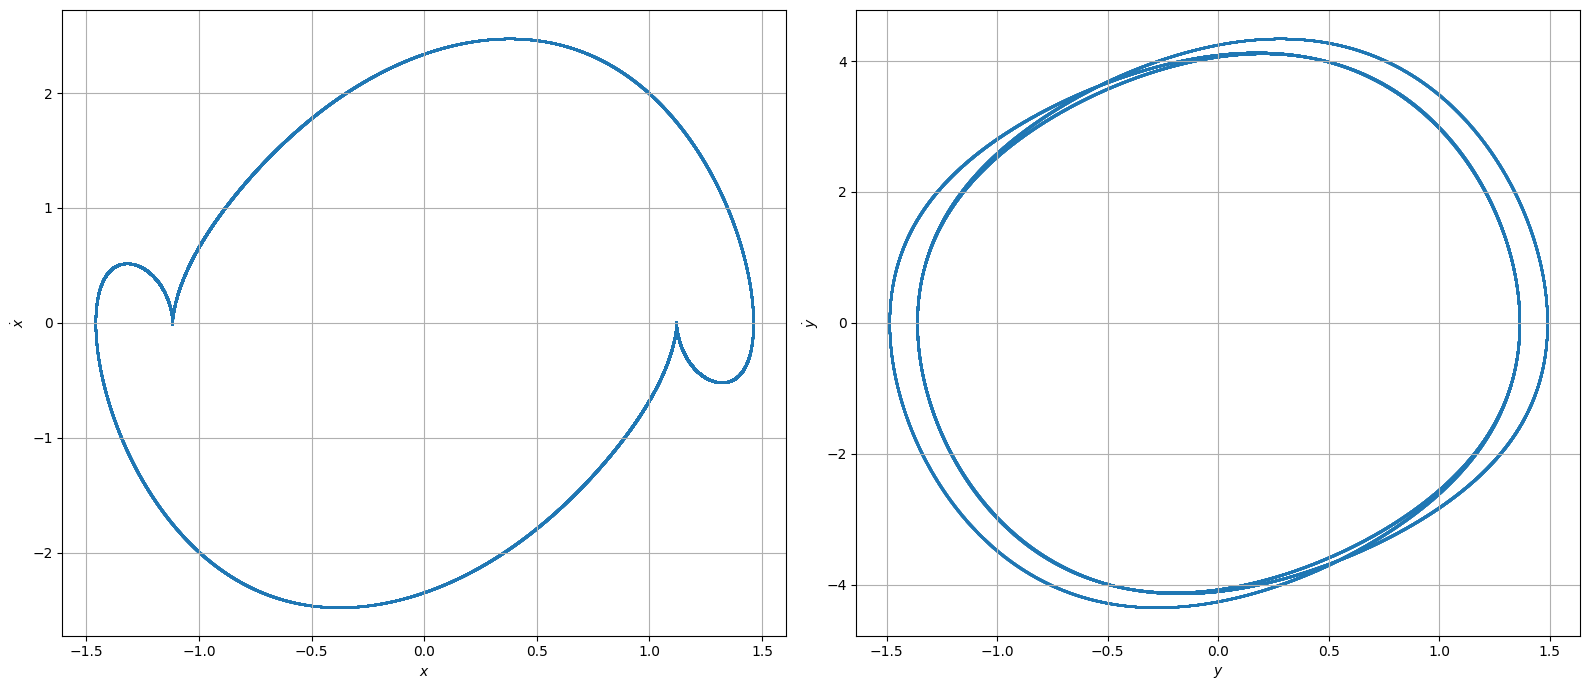

In [ ]:
plot_phase_portrait(state=[1.0, 0.0, 1.0, 0.0], params=[1.0, 8, 0.5], dt=0.01, n_transient=200, n_attractor=100)

In [93]:
def secant_plane_alt(state):
    return state[1]

p1 = calculate_period(state=[0.5, 0.6, 0.7, 0.8], params=[1.0, 8, 0.5], dt=0.01, n_transient=500, n_attractor=500,
                      secant_plane=secant_plane_alt, accuracy=1e-1)
p2 = calculate_period(state=[0.5, 0.6, 0.7, 0.8], params=[1.0, 8, 0.5], dt=0.01, n_transient=500, n_attractor=500,
                      secant_plane=secant_plane, accuracy=1e-1)

print(p1, p2)
print(p1 / p2)

3 3
1.0


In [91]:
state=[0.5, 0.6, 0.7, 0.8]
params=[1.0, 8, 0.5]
dt=0.01
n_transient=300
n_attractor=300
state = pass_transient_process(state, params, dt, n_transient)
number_of_intersections = 0
previous_state = None
first_point = None
intersections = []
distances = []

while number_of_intersections < n_attractor:
    previous_state = state
    state = rk4_step(state, params, dt)

    if previous_state is not None:
        S_prev = secant_plane_alt(previous_state)
        S_curr = secant_plane_alt(state)

        if S_prev < 0 and S_curr >= 0:
            dS = -S_curr
            
            sect_point = henon_rk4_step(state, params, dS)
            intersections.append(sect_point)

            if first_point is None:
                first_point = sect_point
            else:
                distances.append(np.linalg.norm(sect_point - first_point))
                if np.linalg.norm(sect_point - first_point) < 1e-3:
                    print(number_of_intersections)
            
            if sect_point is not None:
                number_of_intersections += 1
            else:
                print(f"Error: henon_rk4_step failed at intersection {number_of_intersections+1}")

297


In [92]:
distances[1:10]

[np.float64(5.405761292980496),
 np.float64(0.029061320608114366),
 np.float64(2.595429058309719),
 np.float64(5.381287030198408),
 np.float64(0.05829244467210247),
 np.float64(2.5918723603398726),
 np.float64(5.453936155139743),
 np.float64(0.027761216502327636),
 np.float64(2.588740520411146)]

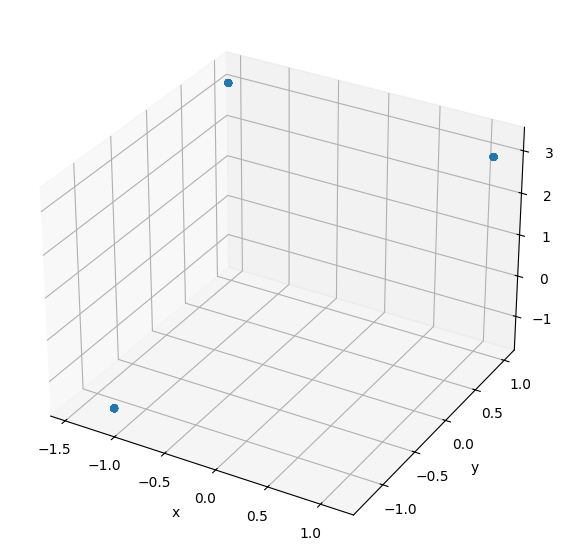

In [86]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

intersections = np.array(intersections)
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(intersections[:, 0], intersections[:, 2], intersections[:, 3])
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.show()

# Соотношение частот

In [10]:
def calculate_all_periods(state, params, dt, n_transient, n_cycles=5):
    """
    Вычисляет временные периоды для всех подсистем и системы в целом.
    
    Параметры:
    state: начальное состояние [x1, dx1, x2, dx2]
    params: параметры системы [lambda_, delta, mu]
    dt: шаг интегрирования
    n_transient: количество пересечений для пропуска переходного процесса
    n_cycles: количество циклов для усреднения периода
    
    Возвращает:
    dict: словарь с периодами или кодами ошибок:
      - 'x1': период колебаний по переменной x1
      - 'x2': период колебаний по переменной x2  
      - 'system': общий период системы
      - 'error': общая ошибка (если есть)
    """
    # Пропускаем переходный процесс
    current_state = pass_transient_process(state, params, dt, n_transient)
    if current_state is None:
        return {'x1': -2, 'x2': -2, 'system': -2, 'error': 'Расходимость системы'}
    
    # Функции для проверки пересечений
    def check_positive_crossing(prev, curr, index):
        return prev[index] < 0 and curr[index] >= 0
    
    def check_negative_crossing(prev, curr, index):
        return prev[index] > 0 and curr[index] <= 0
    
    # Собираем времена пересечений для всех переменных
    times_x1_pos, times_x1_neg = [], []
    times_x2_pos, times_x2_neg = [], []
    
    previous_state = current_state
    t_total = 0.0
    cross_count = 0
    max_steps = 1000000
    
    # Интегрируем и собираем данные о пересечениях
    while cross_count < n_cycles * 2:  # Умножаем на 2, так как собираем оба направления
        current_state = rk4_step(previous_state, params, dt)
        if current_state is None:
            return {'x1': -2, 'x2': -2, 'system': -2, 'error': 'Расходимость системы'}
        
        t_total += dt
        
        # Проверяем пересечения для x1
        if check_positive_crossing(previous_state, current_state, 0):
            y_prev = previous_state[0]
            y_curr = current_state[0]
            fraction = -y_prev / (y_curr - y_prev)
            precise_time = t_total - dt + fraction * dt
            times_x1_pos.append(precise_time)
            cross_count += 1
            
        if check_negative_crossing(previous_state, current_state, 0):
            y_prev = previous_state[0]
            y_curr = current_state[0]
            fraction = y_prev / (y_prev - y_curr)
            precise_time = t_total - dt + fraction * dt
            times_x1_neg.append(precise_time)
            cross_count += 1
        
        # Проверяем пересечения для x2
        if check_positive_crossing(previous_state, current_state, 2):
            y_prev = previous_state[2]
            y_curr = current_state[2]
            fraction = -y_prev / (y_curr - y_prev)
            precise_time = t_total - dt + fraction * dt
            times_x2_pos.append(precise_time)
            
        if check_negative_crossing(previous_state, current_state, 2):
            y_prev = previous_state[2]
            y_curr = current_state[2]
            fraction = y_prev / (y_prev - y_curr)
            precise_time = t_total - dt + fraction * dt
            times_x2_neg.append(precise_time)
        
        previous_state = current_state
        
        if t_total > max_steps * dt:
            return {'x1': -3, 'x2': -3, 'system': -3, 'error': 'Превышено максимальное время'}
    
    # Вычисляем периоды для каждой подсистемы
    period_x1_pos = np.mean([times_x1_pos[i] - times_x1_pos[i-1] for i in range(1, len(times_x1_pos))]) if len(times_x1_pos) > 1 else -3
    period_x1_neg = np.mean([times_x1_neg[i] - times_x1_neg[i-1] for i in range(1, len(times_x1_neg))]) if len(times_x1_neg) > 1 else -3
    period_x1 = (period_x1_pos + period_x1_neg) / 2 if period_x1_pos > 0 and period_x1_neg > 0 else max(period_x1_pos, period_x1_neg)
    
    period_x2_pos = np.mean([times_x2_pos[i] - times_x2_pos[i-1] for i in range(1, len(times_x2_pos))]) if len(times_x2_pos) > 1 else -3
    period_x2_neg = np.mean([times_x2_neg[i] - times_x2_neg[i-1] for i in range(1, len(times_x2_neg))]) if len(times_x2_neg) > 1 else -3
    period_x2 = (period_x2_pos + period_x2_neg) / 2 if period_x2_pos > 0 and period_x2_neg > 0 else max(period_x2_pos, period_x2_neg)
    
    # Вычисляем общий период системы (среднее между периодами подсистем)
    if period_x1 > 0 and period_x2 > 0:
        period_system = (period_x1 + period_x2) / 2
    else:
        period_system = max(period_x1, period_x2)
    
    return {
        'x1': period_x1,
        'x2': period_x2,
        'system': period_system,
        'error': None
    }

# Пример использования
initial_state = [0.1, 0.0, 0.2, 0.0]
parameters = [1.0, 8, 0.5]
dt = 0.01

periods = calculate_all_periods(
    initial_state,
    parameters,
    dt,
    n_transient=100,
    n_cycles=10
)

if periods['error'] is None:
    freq_x1 = periods['x1'] / (2 * np.pi)
    freq_x2 = periods['x2'] / (2 * np.pi)
    freq_system = periods['system'] / (2 * np.pi)
    print(f"Частота колебаний x1: {freq_x1:.4f}")
    print(f"Частота колебаний x2: {freq_x2:.4f}")
    print(f"Общая частота системы: {freq_system:.4f}")
else:
    print(f"Ошибка: {periods['error']}")

Частота колебаний x1: 1.0214
Частота колебаний x2: 0.3403
Общая частота системы: 0.6809
